In [819]:
%run Wiskunde_II_Portfolio.ipynb

Mean Absolute Error: 595.83 KG CO2 per jaar
De b0 waarde van de formule is: -2469.5453013648957
De coëfficiënten van de formule zijn: [ 1.76165502e-04  5.12507767e-01  1.22929621e+00  1.13500223e-03
  9.76417156e+00  8.12003925e+00  4.41754945e-01  4.76441713e-02
  9.80341633e-02  2.47979508e-01  6.91927479e+01  1.82934092e+01
 -4.41410212e+01  7.71317118e+01 -6.76496661e+01  2.59989476e+03
  4.09688211e+01  7.76932850e+01  2.30856013e+02  1.98339679e+02
  7.50686327e+01  1.62868647e+02  2.32954144e+02  4.04572435e+01
  1.95279861e+02  1.26682572e+02  1.14671477e+02 -2.64502794e+01
 -8.92662444e+00 -1.05930208e+02 -3.67333815e+01  1.88290190e+01]
Voorspelling: 1242.71 KG CO2 per jaar


C:\Users\schur\AppData\Local\Temp\ipykernel_6228\1424262690.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed = df_transformed.replace(mapdict)


In [820]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [821]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 200)

In [822]:
df_transformed

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar
0,811069,50,52.66,48003.64,5,1,13266.05,2040.54,3227.95,480.71,1,20,1,7591.93,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,246882,65,64.58,55208.63,2,3,15229.89,0.00,2298.96,1423.34,0,7,2,8742.25,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
2,978385,49,90.87,29533.78,2,2,19853.24,1540.46,4504.21,632.48,1,2,5,4513.56,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3,120468,34,80.43,44453.27,2,2,9935.50,1825.92,4407.56,1266.84,2,21,2,6904.41,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,637034,60,72.28,56497.64,2,1,16266.67,1851.07,1936.12,1676.00,5,0,1,4420.80,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,838823,78,85.84,28295.50,1,2,6383.24,3672.70,3085.83,1254.60,0,11,2,4251.29,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
1496,964501,54,85.09,45963.45,5,1,18050.72,1907.56,1247.67,907.07,1,3,2,4615.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1497,659695,48,71.79,43443.92,5,2,6860.47,1568.27,1051.74,1385.12,0,13,1,4631.48,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1498,883394,76,69.02,33158.29,4,1,0.00,2170.89,1978.18,364.76,0,15,1,786.82,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [823]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   persoon_ID                             1500 non-null   int64  
 1   leeftijd                               1500 non-null   int64  
 2   gewicht_KG                             1500 non-null   float64
 3   jaarsalaris_eu                         1500 non-null   float64
 4   huishouden_grootte                     1500 non-null   int64  
 5   opleiding_niveau                       1500 non-null   int64  
 6   km_auto_per_jaar                       1500 non-null   float64
 7   km_fiets_per_jaar                      1500 non-null   float64
 8   km_ov_per_jaar                         1500 non-null   float64
 9   km_vliegtuig_per_jaar                  1500 non-null   float64
 10  dagen_kantoorwerken_per_week_pro_rato  1500 non-null   int64  
 11  dage

In [824]:
#feature_eng_cols = ['km_totaal', 'aandeel_auto', 'aandeel_vliegtuig', 'kantoor_dagen_per_jaar', 'hoog_uitstoot_gedrag']

#raw_eng_cols = ['km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_kantoorwerken_per_week_pro_rato']

#df_transformed = df_transformed.drop(raw_eng_cols, axis=1)

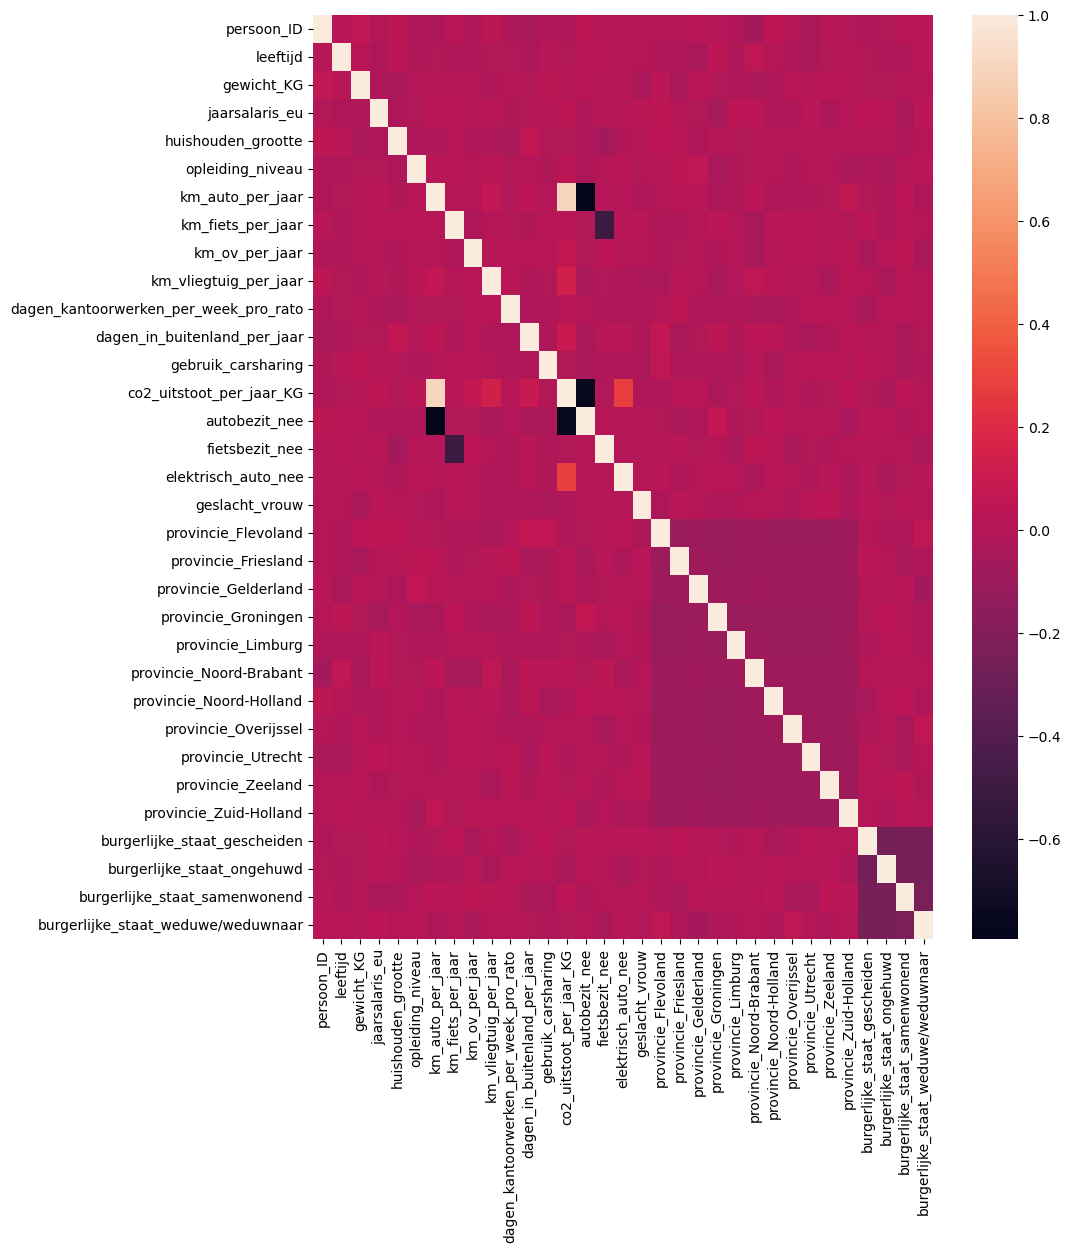

In [825]:
plt.figure(figsize=(10, 12))

sns.heatmap(df_transformed.corr(method='spearman'))

plt.show()

In [826]:
df[modus_cols]


,geslacht,burgerlijke_staat,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,gebruik_carsharing
0,man,weduwe/weduwnaar,Flevoland,MBO,ja,ja,nee,Nooit
1,vrouw,samenwonend,Overijssel,WO,ja,nee,nee,Heel soms
2,man,samenwonend,Utrecht,HBO,ja,ja,ja,Altijd
3,man,gehuwd,Utrecht,HBO,ja,ja,nee,Heel soms
4,man,ongehuwd,Gelderland,MBO,ja,ja,ja,Nooit
...,...,...,...,...,...,...,...,...
1495,man,weduwe/weduwnaar,Noord-Holland,HBO,ja,ja,nee,Heel soms
1496,man,ongehuwd,Drenthe,MBO,ja,ja,ja,Heel soms
1497,man,weduwe/weduwnaar,Flevoland,HBO,ja,ja,nee,Nooit
1498,man,gehuwd,Drenthe,MBO,nee,ja,nee,Nooit


In [827]:
import numpy as np

modus_cols = ['geslacht', 'burgerlijke_staat', 'provincie', 'opleiding_niveau', 'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing']

def eta_squared(categorisch, numeriek):
    groepen = [numeriek[categorisch == c] for c in categorisch.unique()]
    grand_mean = numeriek.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groepen)
    ss_total = ((numeriek - grand_mean)**2).sum()
    return ss_between / ss_total

for i in modus_cols:

    print(eta_squared(df[i], df['co2_uitstoot_per_jaar_KG']))


0.0008489676611990393
0.0022113464361503206
0.005266225248031182
0.0021808560349749003
0.5034053830760082
7.53412339514707e-06
0.09018871376382136
0.0032242970587868084


<Axes: >

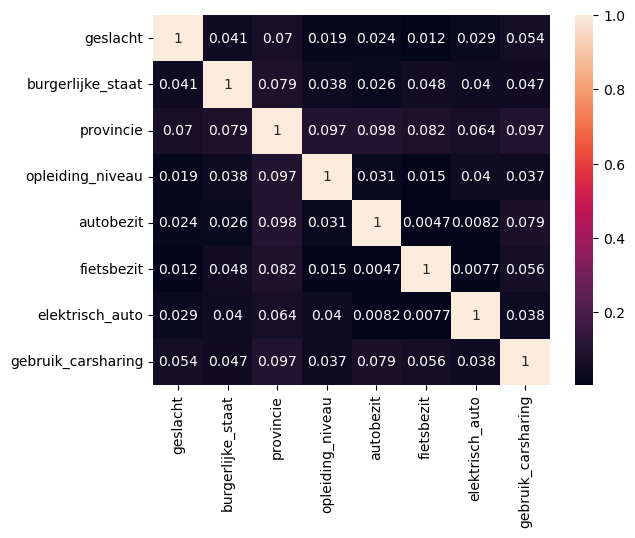

In [828]:
from scipy import stats
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

dicto = {}

for i in modus_cols:
    dicto[i] = {}


    for j in modus_cols:

        dicto[i][j] = cramers_v(df[i], df[j])
        

        

dicto = pd.DataFrame(dicto)

sns.heatmap(dicto, annot=True)

In [829]:
corr_target

,co2_uitstoot_per_jaar_KG
co2_uitstoot_per_jaar_KG,1.000000
km_auto_per_jaar,0.903283
elektrisch_auto_nee,0.300314
km_vliegtuig_per_jaar,0.105816
dagen_in_buitenland_per_jaar,0.087038
km_ov_per_jaar,0.060919
jaarsalaris_eu,0.042682
provincie_Zuid-Holland,0.037344
provincie_Friesland,0.031346
opleiding_niveau,0.025809


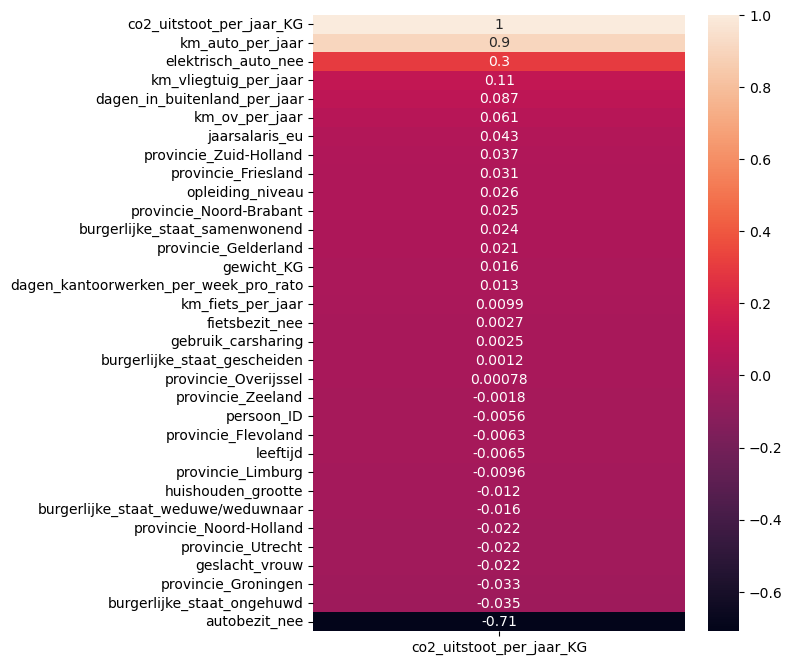

In [830]:
corr_target = df_transformed.corrwith(df_transformed['co2_uitstoot_per_jaar_KG']).sort_values(ascending=False).to_frame(name='co2_uitstoot_per_jaar_KG')

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True)

plt.show()

In [877]:
X = df_transformed.drop(['co2_uitstoot_per_jaar_KG', 'persoon_ID'], axis=1)
y = df_transformed['co2_uitstoot_per_jaar_KG']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)







In [878]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor



In [879]:
numerieke_cols = X_train.select_dtypes(exclude='bool').columns

scaler = StandardScaler()

X_train[numerieke_cols] = scaler.fit_transform(X_train[numerieke_cols])

X_test[numerieke_cols] = scaler.transform(X_test[numerieke_cols])


In [880]:
model = RandomForestRegressor()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model.score(X_test, y_test)

0.9700040640636268

In [881]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model.score(X_test, y_test)

0.9360073548306056

In [882]:
y_pred = model.predict(X_test)
score = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {score:.2f} KG CO2 per jaar")



print(f"De b0 waarde van de formule is: {model.intercept_}")
print(f"De coëfficiënten van de formule zijn: {model.coef_}")

Mean Absolute Error: 592.17 KG CO2 per jaar
De b0 waarde van de formule is: 2676.7935806311025
De coëfficiënten van de formule zijn: [  10.23167972   19.70071411   17.11750589   17.33674701    6.23119118
 3119.20756854   36.80244947  136.52333367  188.27339121  114.40977586
  157.37555241  -53.82882185   86.91174531  -63.77012695 2600.64080436
   43.93660861   73.74577864  228.95182655  200.17543064   69.96172727
  153.84299828  217.73608988   45.60605799  192.04409879  116.93826194
  114.11324071  -33.92970099  -10.10241943 -103.99617015  -35.29189751
   21.59255742]


In [883]:
model.coef_

array([  10.23167972,   19.70071411,   17.11750589,   17.33674701,
          6.23119118, 3119.20756854,   36.80244947,  136.52333367,
        188.27339121,  114.40977586,  157.37555241,  -53.82882185,
         86.91174531,  -63.77012695, 2600.64080436,   43.93660861,
         73.74577864,  228.95182655,  200.17543064,   69.96172727,
        153.84299828,  217.73608988,   45.60605799,  192.04409879,
        116.93826194,  114.11324071,  -33.92970099,  -10.10241943,
       -103.99617015,  -35.29189751,   21.59255742])

(array([445., 181., 220., 239., 220., 123.,  52.,  15.,   4.,   1.]),
 array([    0.   ,  1809.844,  3619.688,  5429.532,  7239.376,  9049.22 ,
        10859.064, 12668.908, 14478.752, 16288.596, 18098.44 ]),
 <BarContainer object of 10 artists>)

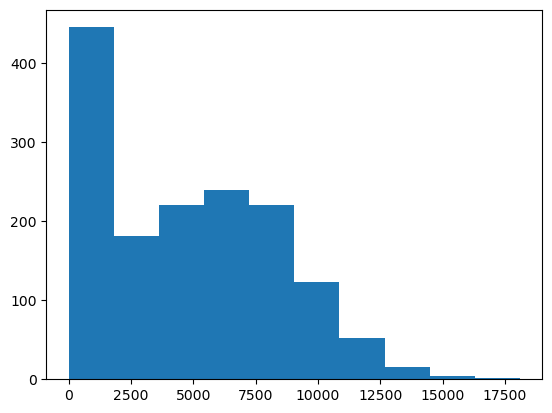

In [884]:
plt.hist(df_transformed.co2_uitstoot_per_jaar_KG)

In [894]:
mu = df['co2_uitstoot_per_jaar_KG'].mean()
sigma = df['co2_uitstoot_per_jaar_KG'].std()

z = (5000 - mu) / sigma

kans = 1- stats.norm.cdf(z) 

kans

np.float64(0.48963256070214634)